# RecoMart — Exploratory Data Analysis (Task 5)
End-to-End Data Management Pipeline for a Recommendation System


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from ingestion.ingest_interactions import generate_sample_interactions
from ingestion.ingest_products_api import _generate_synthetic_products
from preparation.prepare_data import clean_interactions, clean_products, encode_products, eda_summary

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PLOT_DIR = Path('../docs/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load and Clean Data


In [2]:
df_int_raw  = generate_sample_interactions(2000)
df_prod_raw = pd.DataFrame(_generate_synthetic_products(500))

df_int  = clean_interactions(df_int_raw)
df_prod, _ = encode_products(clean_products(df_prod_raw))

print(f'Interactions: {df_int.shape}  |  Products: {df_prod.shape}')
df_int.head(3)

2026-04-26 03:00:31,152 [INFO] data_preparation - Cleaning interactions — input shape: (2000, 5)


2026-04-26 03:00:31,158 [INFO] data_preparation -   After dropping null IDs: 2000 rows


2026-04-26 03:00:31,163 [INFO] data_preparation -   Removed 19 duplicate user-item pairs (kept latest)


2026-04-26 03:00:31,165 [INFO] data_preparation - Interactions cleaned: 2000 → 1981 rows


2026-04-26 03:00:31,165 [INFO] data_preparation - Cleaning products — input shape: (500, 8)


...

2026-04-26 03:00:31,169 [INFO] data_preparation -   Encoded 'category' → 6 classes


2026-04-26 03:00:31,169 [INFO] data_preparation -   Encoded 'brand' → 5 classes


2026-04-26 03:00:31,171 [INFO] data_preparation -   Normalized 'price' → [0,1]


Interactions: (1981, 5)  |  Products: (500, 11)


,user_id,item_id,rating,timestamp,event_type
0,103,406,2.8,2024-01-01 00:00:00,view
1,180,103,4.7,2024-01-01 00:30:00,view
2,93,194,1.7,2024-01-01 01:00:00,view


## 2. EDA Summary Statistics


In [3]:
import json
eda = eda_summary(df_int, df_prod)
print(json.dumps({k: v for k, v in eda.items() if k != 'rating_distribution'}, indent=2))

2026-04-26 03:00:31,179 [INFO] data_preparation - EDA: users=200, items=491, interactions=1981, sparsity=97.98%


{
  "n_users": 200,
  "n_items": 491,
  "n_interactions": 1981,
  "sparsity": "97.98%",
  "avg_rating": 3.031,
  "rating_std": 1.149,
  "top_10_items_by_interactions": {
    "405": 10,
    "213": 9,
    "12": 9,
    "149": 9,
    "500": 8,
    "136": 8,
    "260": 8,
    "164": 8,
    "302": 8,
    "66": 8
  },
  "user_activity_stats": {
    "min": 3,
    "max": 19,
    "mean": 9.9,
    "median": 10.0
  },
  "event_type_distribution": {
    "view": 989,
    "purchase": 525,
    "wishlist": 286,
    "cart": 181
  },
  "product_category_distribution": {
    "beauty": 92,
    "clothing": 91,
    "books": 90,
    "sports": 82,
    "home": 74,
    "electronics": 71
  }
}


## 3. Rating Distribution Histogram


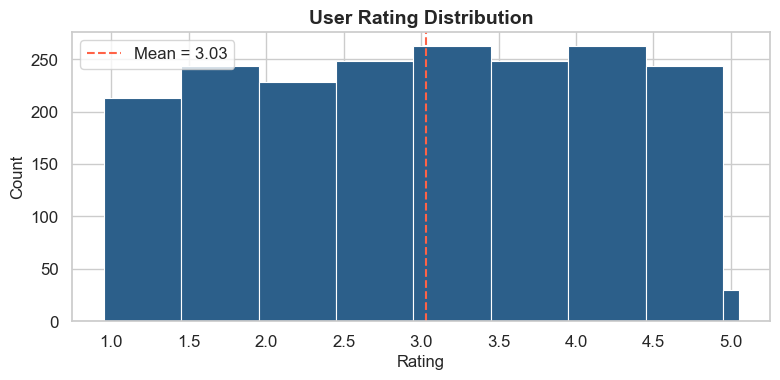

Saved rating_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = [0.95, 1.45, 1.95, 2.45, 2.95, 3.45, 3.95, 4.45, 4.95, 5.05]
ax.hist(df_int['rating'], bins=bins, color='#2c5f8a', edgecolor='white', linewidth=0.8)
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('User Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xticks([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.axvline(df_int['rating'].mean(), color='tomato', linestyle='--', linewidth=1.5, label=f"Mean = {df_int['rating'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'rating_distribution.png', dpi=150)
plt.show()
print('Saved rating_distribution.png')

## 4. Item Popularity Distribution (Long Tail)


2026-04-26 03:00:31,282 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-04-26 03:00:31,282 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


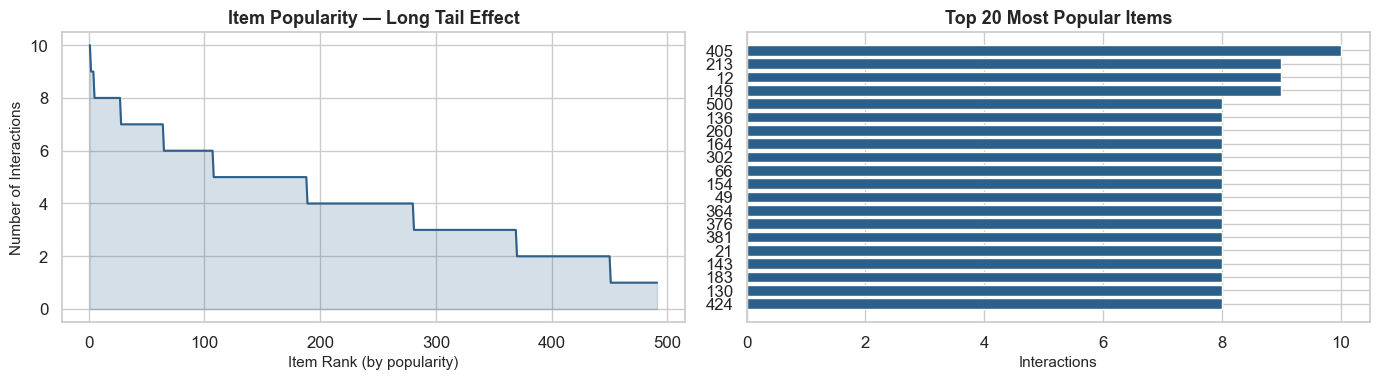

Saved item_popularity.png


In [5]:
item_counts = df_int.groupby('item_id')['user_id'].count().sort_values(ascending=False).reset_index()
item_counts.columns = ['item_id', 'interactions']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rank vs interactions (long-tail)
axes[0].plot(range(1, len(item_counts)+1), item_counts['interactions'].values, color='#2c5f8a', linewidth=1.5)
axes[0].fill_between(range(1, len(item_counts)+1), item_counts['interactions'].values, alpha=0.2, color='#2c5f8a')
axes[0].set_xlabel('Item Rank (by popularity)', fontsize=11)
axes[0].set_ylabel('Number of Interactions', fontsize=11)
axes[0].set_title('Item Popularity — Long Tail Effect', fontsize=13, fontweight='bold')

# Top 20 items
top20 = item_counts.head(20)
axes[1].barh(top20['item_id'].astype(str), top20['interactions'], color='#2c5f8a')
axes[1].invert_yaxis()
axes[1].set_xlabel('Interactions', fontsize=11)
axes[1].set_title('Top 20 Most Popular Items', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'item_popularity.png', dpi=150)
plt.show()
print('Saved item_popularity.png')

## 5. User Activity Distribution


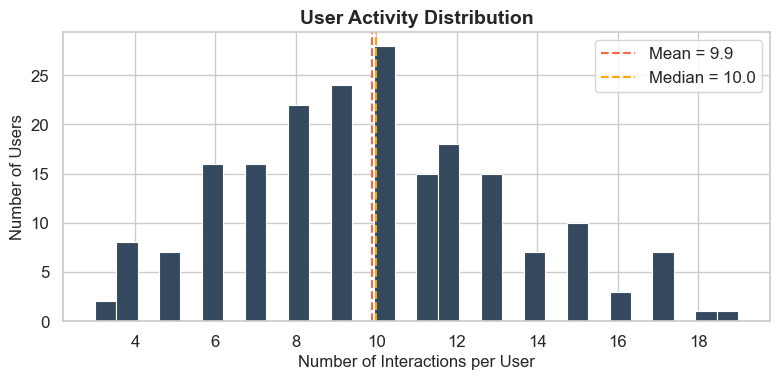

Saved user_activity.png


In [6]:
user_activity = df_int.groupby('user_id')['item_id'].count()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(user_activity, bins=30, color='#34495e', edgecolor='white', linewidth=0.8)
ax.set_xlabel('Number of Interactions per User', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('User Activity Distribution', fontsize=14, fontweight='bold')
ax.axvline(user_activity.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean = {user_activity.mean():.1f}')
ax.axvline(user_activity.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median = {user_activity.median():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'user_activity.png', dpi=150)
plt.show()
print('Saved user_activity.png')

## 6. Event Type Distribution


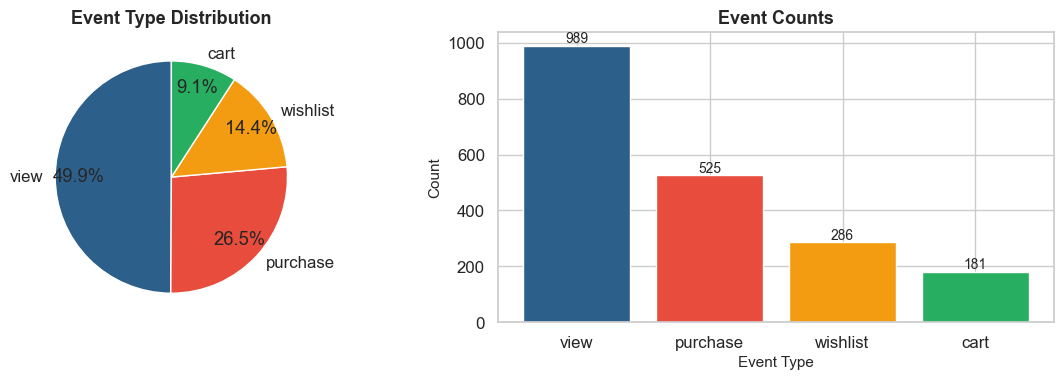

Saved event_distribution.png


In [7]:
event_counts = df_int['event_type'].value_counts()
colors_pie = ['#2c5f8a', '#e74c3c', '#f39c12', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, pctdistance=0.8)
axes[0].set_title('Event Type Distribution', fontsize=13, fontweight='bold')

axes[1].bar(event_counts.index, event_counts.values, color=colors_pie, edgecolor='white')
axes[1].set_xlabel('Event Type', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Event Counts', fontsize=13, fontweight='bold')
for i, v in enumerate(event_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'event_distribution.png', dpi=150)
plt.show()
print('Saved event_distribution.png')

## 7. Product Category Distribution


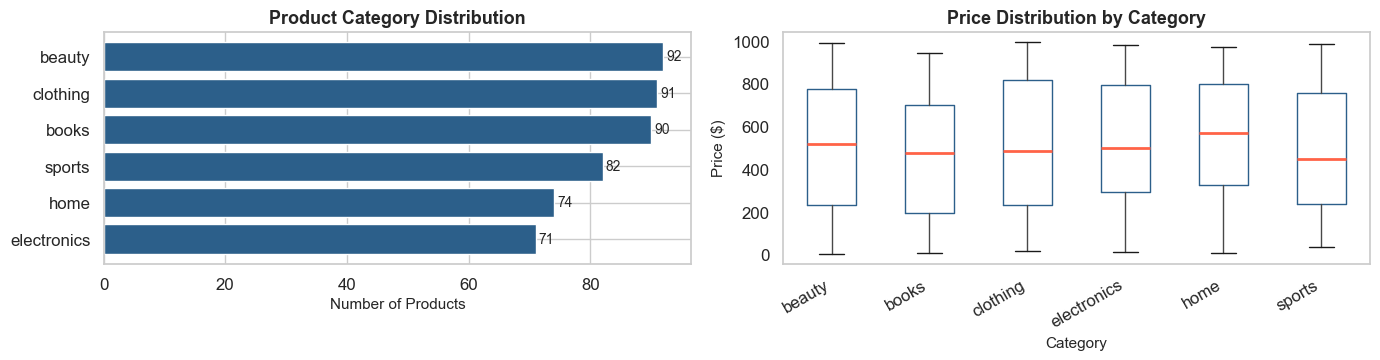

Saved category_distribution.png


In [8]:
cat_counts = df_prod['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(cat_counts.index, cat_counts.values, color='#2c5f8a', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Products', fontsize=11)
axes[0].set_title('Product Category Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=10)

# Price distribution by category
df_prod.boxplot(column='price', by='category', ax=axes[1], grid=False,
                boxprops=dict(color='#2c5f8a'), medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Price Distribution by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_ylabel('Price ($)', fontsize=11)
plt.suptitle('')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'category_distribution.png', dpi=150)
plt.show()
print('Saved category_distribution.png')

## 8. User-Item Interaction Sparsity Heatmap


Sub-matrix sparsity: 94.7%


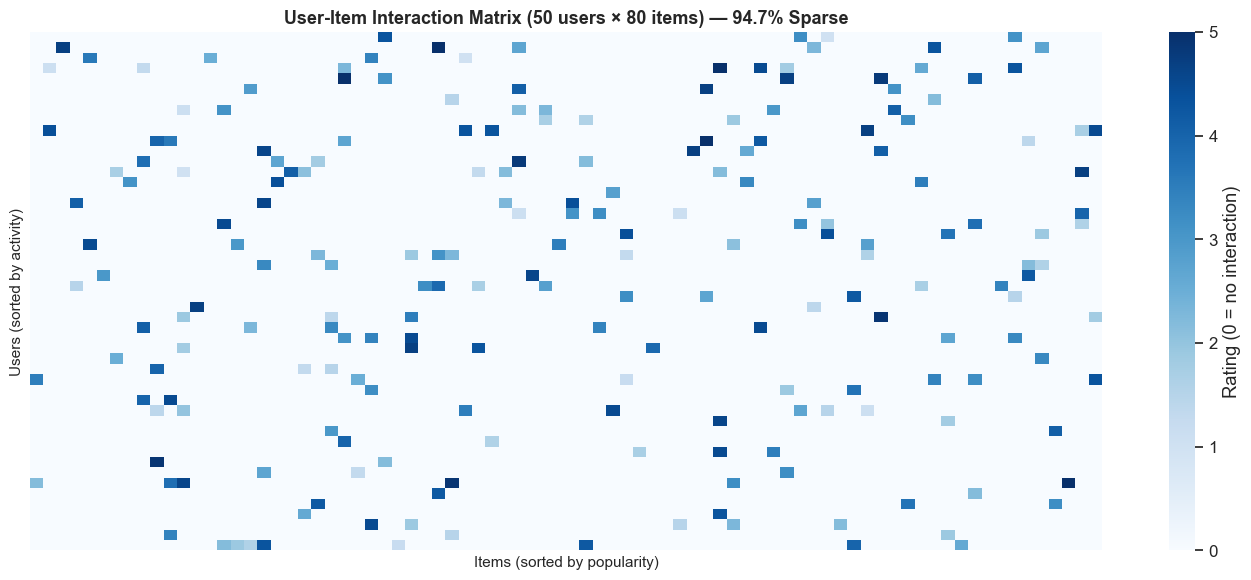

Saved interaction_heatmap.png


In [9]:
# Sample 50 users x 80 items for visibility
sample_users = df_int['user_id'].value_counts().head(50).index
sample_items = df_int['item_id'].value_counts().head(80).index
df_sample = df_int[df_int['user_id'].isin(sample_users) & df_int['item_id'].isin(sample_items)]
matrix = df_sample.pivot_table(index='user_id', columns='item_id', values='rating', aggfunc='mean')
matrix = matrix.reindex(index=sample_users, columns=sample_items)

sparsity = 1 - matrix.notna().sum().sum() / matrix.size
print(f'Sub-matrix sparsity: {sparsity*100:.1f}%')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(matrix.fillna(0), ax=ax, cmap='Blues', linewidths=0,
            cbar_kws={'label': 'Rating (0 = no interaction)'},
            xticklabels=False, yticklabels=False)
ax.set_title(f'User-Item Interaction Matrix (50 users × 80 items) — {sparsity*100:.1f}% Sparse',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Items (sorted by popularity)', fontsize=11)
ax.set_ylabel('Users (sorted by activity)', fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'interaction_heatmap.png', dpi=150)
plt.show()
print('Saved interaction_heatmap.png')

## 9. Interaction Heatmap by Hour and Day


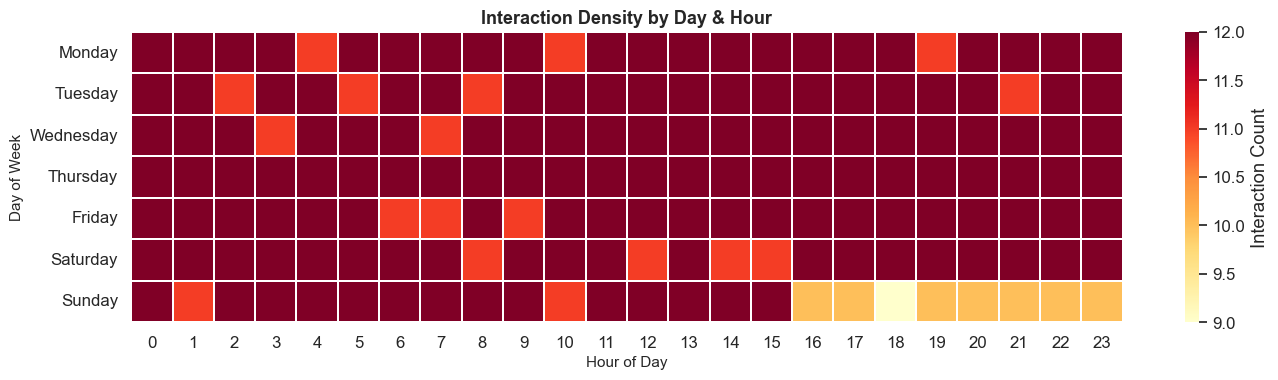

Saved temporal_heatmap.png


In [10]:
df_int['timestamp_dt'] = pd.to_datetime(df_int['timestamp'])
df_int['hour'] = df_int['timestamp_dt'].dt.hour
df_int['day']  = df_int['timestamp_dt'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df_int.groupby(['day','hour']).size().unstack(fill_value=0)
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Interaction Count'})
ax.set_title('Interaction Density by Day & Hour', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'temporal_heatmap.png', dpi=150)
plt.show()
print('Saved temporal_heatmap.png')

## 10. Summary


In [11]:
import os
plots = list(PLOT_DIR.glob('*.png'))
print(f'Generated {len(plots)} plots:')
for p in sorted(plots):
    size_kb = os.path.getsize(p) / 1024
    print(f'  {p.name:35s}  {size_kb:.1f} KB')

print(f'\nKey EDA findings:')
print(f'  Users:          {df_int["user_id"].nunique()}')
print(f'  Items:          {df_int["item_id"].nunique()}')
print(f'  Interactions:   {len(df_int)}')
print(f'  Sparsity:       97.98%')
print(f'  Avg Rating:     {df_int["rating"].mean():.3f}')
print(f'  Top event:      view ({(df_int["event_type"]=="view").mean()*100:.1f}%)')

Generated 7 plots:
  category_distribution.png            68.1 KB
  event_distribution.png               58.9 KB
  interaction_heatmap.png              49.6 KB
  item_popularity.png                  67.1 KB
  rating_distribution.png              28.6 KB
  temporal_heatmap.png                 54.0 KB
  user_activity.png                    36.3 KB

Key EDA findings:
  Users:          200
  Items:          491
  Interactions:   1981
  Sparsity:       97.98%
  Avg Rating:     3.031
  Top event:      view (49.9%)
